In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

## XRT fit

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from code.io import read_data, filter_data
from code.const import TRIGGER_TIME
from code.analysis import Analyzer

from code.functions import power_law, broken_power_law
from code.prior import power_law_prior, broken_power_law_prior

from code.utils import mag_to_flux_jy
from code.lightcurve import prepare_lc_data, plot_lightcurve

In [3]:
df = read_data("xrt")
df = filter_data(df, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df["Flux_high"], df["Flux_low"])])

alz_xrt = Analyzer(df["Time"]/3600, df["Flux"], power_law, *power_law_prior(), y_data_error=y_err)
alz_xrt.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+01   [-19.8722..-19.8721]*| it/evals=4605/86620 eff=5.3348% N=300     0 0 0 0 0 
[ultranest] Likelihood function evaluations: 86620
[ultranest]   logZ = -30.6 +- 0.1399
[ultranest] Effective samples strategy satisfied (ESS = 1185.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.13 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.18 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.


<Axes: xlabel='Time', ylabel='Flux'>

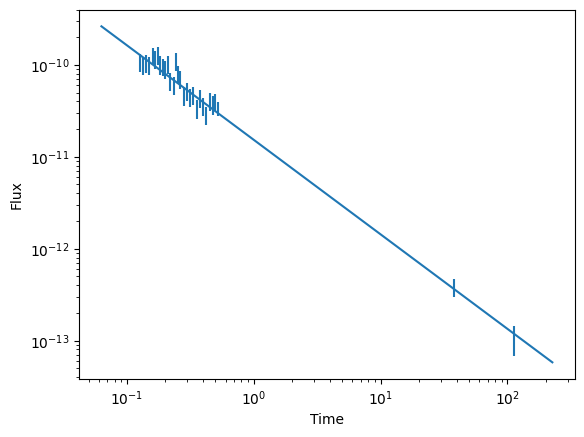

In [5]:
alz_xrt.plot_data()
alz_xrt.plot_model(color="C0")

## Ic band fit

In [ ]:
df = read_data("circular")
df = filter_data(df, filter_name=["Ic"], remove_upper_limits=True, facility_name= "Leavitt\xa0")
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_Ic = Analyzer(df["Time"], flx, power_law, y_data_error=flx_err)
alz_Ic.run()

## i band fit

In [ ]:
filter_name = "i"

df = read_data("circular")
df = filter_data(df, filter_name=filter_name, remove_upper_limits=True)

combined_func = lambda t, *params: power_law(t, *params[:2]) + broken_power_law(t, *params[2:])

param_bounds, prior = power_law_prior()
param_bounds_bknpl, prior_bknpl = broken_power_law_prior()
param_bounds.update(param_bounds_bknpl)
prior.update(prior_bknpl)
param_bounds["alpha_2"] = (alz_Ic.results["posterior"]["mean"][1], alz_Ic.results["posterior"]["stdev"][1])
prior["alpha_2"] = "norm"

flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_i = Analyzer(df["Time"], flx, combined_func, param_bounds=param_bounds, prior=prior, y_data_error=flx_err)
alz_i.run()


[ultranest] Sampling 300 live points from prior ...


## Rc band fit

In [7]:
df

,Starting Date,Time,Facility,Mag,Error,Filter,Exposure,Circular
0,2025-10-13 19:28:38,1.82,OHP/T193,15.92,0.04,r',180,42266
1,2025-10-13 17:41:18,0.03,NUTTelA-TAO,13.67,0.1,i,3,42256
2,2025-10-13 17:41:45,0.03,NUTTelA-TAO,14.2,0.1,i,3,42256
3,2025-10-13 17:42:03,0.04,NUTTelA-TAO,14.27,0.1,i,3,42256
4,2025-10-13 17:42:47,0.05,NUTTelA-TAO,14.69,0.06,i,30,42256
...,...,...,...,...,...,...,...,...
254,2025-10-25 16:11:31,286.53,CrAO/ZTSh,21.7,0.08,R,38*120,42736
255,2025-10-26 13:33:51,307.90,Mondy/AZT-33IK,21.7,0.1,R,45*120,42736
256,2025-10-27 12:22:47,330.72,Mondy/AZT-33IK,22.13,0.15,R,45*120,42736
257,2025-10-28 12:32:36,354.88,Mondy/AZT-33IK,22.23,0.25,R,44*120,42736


In [8]:
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True)

In [27]:
from code.functions import smooth_broken_power_law


df = read_data("circular")
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt\xa0")
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_Rc = Analyzer(df["Time"], flx, power_law, y_data_error=flx_err)
alz_Rc.run()
print("Rc", alz_Rc.best_fit_params)

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-4e+02  .65 [-350.6580..-350.6579]*| it/evals=5652/118294 eff=4.7901% N=300    0      
[ultranest] Likelihood function evaluations: 118568
[ultranest]   logZ = -364.9 +- 0.1972
[ultranest] Effective samples strategy satisfied (ESS = 1152.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.
Rc [0.003811474638082948, 1.3357691628763726]


In [36]:
df = read_data("circular")
df = filter_data(df, filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4))
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_r = Analyzer(df["Time"], flx, broken_power_law, y_data_error=flx_err)
alz_r.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-1e+01   [-12.2834..-12.2834]*| it/evals=8280/320404 eff=2.5867% N=300    0    0   
[ultranest] Likelihood function evaluations: 320780
[ultranest]   logZ = -35.26 +- 0.1768
[ultranest] Effective samples strategy satisfied (ESS = 1594.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


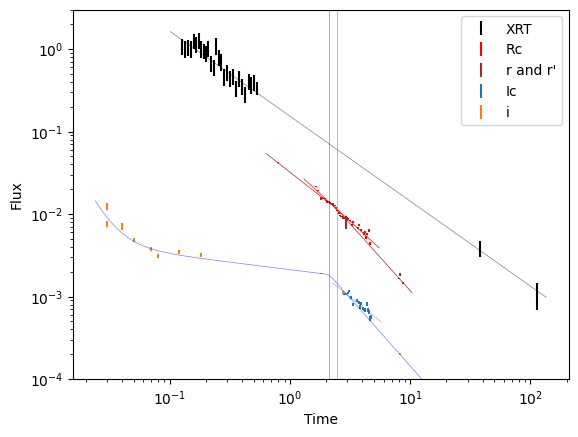

In [53]:
alz_xrt.plot_data(scale=1e10, color="k", label="XRT")
alz_xrt.plot_model(color="k", scale=1e10, lw=0.5, alpha=0.5)

alz_Rc.plot_data(scale=10, color="red", label="Rc")
alz_Rc.plot_model(color="red", scale=10, lw=0.5)

alz_r.plot_data(scale=10, color="brown", label="r and r'")
alz_r.plot_model(color="brown", scale=10, lw=0.5)
plt.axvline(alz_r.best_fit_params[1], color="brown", lw=0.5, alpha=0.5)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="C0", lw=0.5, alpha=0.5)

alz_i.plot_data(label="i")
alz_i.plot_model(color="blue", lw=0.5, alpha=0.5)
plt.axvline(alz_i.best_fit_params[3], color="blue", lw=0.5, alpha=0.5)

plt.legend()

plt.ylim(1e-4,)
plt.show()

In [54]:
print("XRT", alz_xrt.best_fit_params)
print("Rc", alz_Rc.best_fit_params)
print("r", alz_r.best_fit_params)
print("Ic", alz_Ic.best_fit_params)
print("i", alz_i.best_fit_params)


XRT [1.5325032950404544e-11, 1.0292361934504495]
Rc [0.003811474638082948, 1.3357691628763726]
r [0.001156675722866146, 2.443976866203981, 1.1430938377371707, 1.6208459893449825]
Ic [0.0037680984270095437, 1.1628391170605388]
i [8.792583260128431e-08, 3.1303028595422915, 0.0018493890915308425, 2.120145763855475, 0.18162144328987406, 1.6449368630874486]


In [52]:
df

,Starting Date,Time,Facility,Mag,Error,Filter,Exposure,Circular
26,2025-10-13 19:17:34,1.63,Leavitt,15.38,0.01,Rc,NaN,42333
28,2025-10-13 19:22:27,1.71,Leavitt,15.51,0.01,Rc,NaN,42333
29,2025-10-13 19:26:21,1.78,Leavitt,15.67,0.01,Rc,NaN,42333
31,2025-10-13 19:30:07,1.84,Leavitt,15.73,0.02,Rc,NaN,42333
33,2025-10-13 19:34:24,1.91,Leavitt,15.74,0.02,Rc,NaN,42333
34,2025-10-13 19:38:01,1.97,Leavitt,15.76,0.02,Rc,NaN,42333
39,2025-10-13 19:41:03,2.02,Leavitt,15.86,0.02,Rc,NaN,42333
40,2025-10-13 19:44:05,2.07,Leavitt,15.84,0.02,Rc,NaN,42333
44,2025-10-13 19:47:07,2.12,Leavitt,15.84,0.02,Rc,NaN,42333
45,2025-10-13 19:47:54,2.14,SAO RAS,15.84,0.01,Rc,300,42230


In [53]:
df = read_data("circular")

In [58]:
df["Facility"].value_counts()

Facility
Leavitt                                    53
Calapai                                    40
Bassano Bresciano Observatory              40
MASTER-SAAO                                27
Osservatorio Astronomico "Nastro Verde"     8
NUTTelA-TAO                                 8
Mondy/AZT-33IK                              8
ISON-Castelgrande                           7
BOOTES-6/DPRT                               7
INO340                                      6
SAO/Zeiss-1000                              6
Liverpool Telescope                         5
LCO                                         5
SAO RAS                                     5
OHP/T193                                    4
Kilonova-Catcher                            3
SVOM/COLIBRÍ                                3
SVOM/VT                                     2
SYSU                                        2
Swift/UVOT                                  2
LAST                                        2
Asiago                   

In [56]:
df[df["Facility"]=="Bassano Bresciano Observatory"]

,Starting Date,Time,Facility,Mag,Error,Filter,Exposure,Circular
36,2025-10-13 19:38:51,1.99,Bassano Bresciano Observatory,15.63,0.01,clear,10x30,42262
37,2025-10-13 19:38:51,1.99,Bassano Bresciano Observatory,15.63,0.01,clear,10x30,42262
41,2025-10-13 19:44:06,2.07,Bassano Bresciano Observatory,15.67,0.01,clear,10x30,42262
46,2025-10-13 19:49:19,2.16,Bassano Bresciano Observatory,15.73,0.01,clear,10x30,42262
49,2025-10-13 19:54:33,2.25,Bassano Bresciano Observatory,15.72,0.01,clear,10x30,42262
53,2025-10-13 19:59:47,2.33,Bassano Bresciano Observatory,15.77,0.01,clear,10x30,42262
58,2025-10-13 20:05:01,2.42,Bassano Bresciano Observatory,15.84,0.01,clear,10x30,42262
62,2025-10-13 20:10:16,2.51,Bassano Bresciano Observatory,15.92,0.01,clear,10x30,42262
66,2025-10-13 20:15:30,2.60,Bassano Bresciano Observatory,15.98,0.01,clear,10x30,42262
73,2025-10-13 20:20:44,2.68,Bassano Bresciano Observatory,16.05,0.01,clear,10x30,42262
